# Data Exploration

This notebook explores the TorchSig and Panoradio datasets used for modulation classification.

**Contents:**
- Load and inspect TorchSig (synthetic) and Panoradio (real HF) datasets
- Visualize signal constellations by modulation family
- Analyze class distribution and SNR ranges
- Compare synthetic vs real-world signals

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from robust_amc.data import (
    FamilyMapper,
    generate_torchsig_data,
    get_loaders,
    load_config_from_yaml,
    load_panoradio_data,
    load_torchsig_data,
)

# Add src to path if running from notebooks directory
src_path = Path("../src")
if src_path.exists():
    sys.path.insert(0, str(src_path.resolve()))


## 1. Load TorchSig Dataset (Synthetic)

In [2]:
TORCHSIG_CACHE = Path("../data/torchsig_train")

# Generate data if not cached
if not TORCHSIG_CACHE.exists():
    print("Generating TorchSig data (first time only)...")
    generate_torchsig_data(
        TORCHSIG_CACHE,
        num_samples_per_class=2000,
        signal_length=1024,
    )

# Load data
ts_data, ts_labels, ts_snrs = load_torchsig_data(TORCHSIG_CACHE)
ts_mapper = FamilyMapper(Path("../configs/label_maps/torchsig_to_family.yaml"))

print(f"TorchSig Dataset:")
print(f"  Shape: {ts_data.shape}")
print(f"  Families: {ts_mapper.family_names}")
print(f"  SNR range: {ts_snrs.min():.0f} to {ts_snrs.max():.0f} dB")

TorchSig Dataset:
  Shape: (140000, 1024)
  Families: ['PSK', 'FSK', 'AM', 'SSB', 'QAM']
  SNR range: 0 to 20 dB


## 2. Load Panoradio Dataset (Real HF)

Note: Panoradio data requires manual download from https://panoradio-sdr.de/radio-signal-classification-dataset/

In [3]:
PANORADIO_DIR = Path("../data/panoradio")

if PANORADIO_DIR.exists() and (PANORADIO_DIR / "rscd_2048.npy").exists():
    pano_data, pano_labels, pano_snrs = load_panoradio_data(PANORADIO_DIR)
    pano_mapper = FamilyMapper(Path("../configs/label_maps/panoradio_to_family.yaml"))

    print(f"Panoradio Dataset:")
    print(f"  Shape: {pano_data.shape}")
    print(f"  Families: {pano_mapper.family_names}")
    print(f"  SNR range: {pano_snrs.min():.0f} to {pano_snrs.max():.0f} dB")
    has_panoradio = True
else:
    print(f"Panoradio data not found at {PANORADIO_DIR}")
    print("Download from: https://panoradio-sdr.de/radio-signal-classification-dataset/")
    has_panoradio = False

Loaded Panoradio data: (172800, 2048), dtype=complex128
Panoradio Dataset:
  Shape: (172800, 2048)
  Families: ['PSK', 'FSK', 'AM', 'SSB', 'OTHER']
  SNR range: -10 to 25 dB


## 3. Family Distribution (TorchSig)

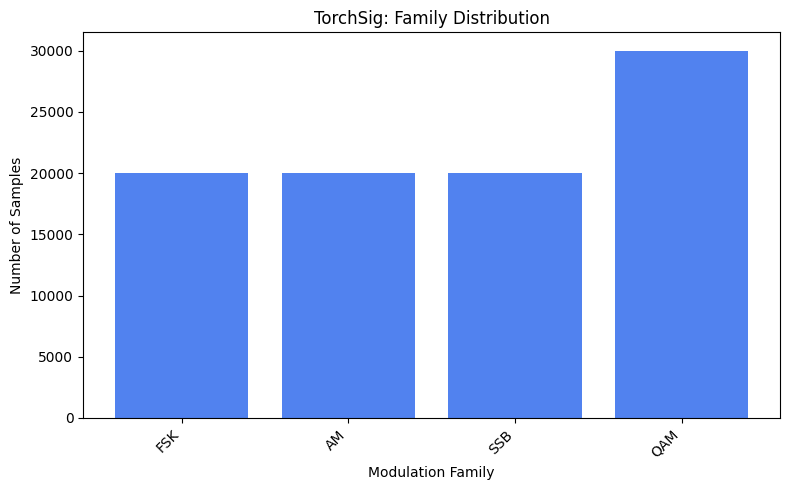


Samples per family:
  FSK: 20000
  AM: 20000
  SSB: 20000
  QAM: 30000


In [4]:
# Map labels to families
ts_family_indices = np.array([ts_mapper.get_family_idx(str(lbl)) or -1 for lbl in ts_labels])
valid_mask = ts_family_indices >= 0

unique, counts = np.unique(ts_family_indices[valid_mask], return_counts=True)

fig, ax = plt.subplots(figsize=(8, 5))
family_names = ts_mapper.family_names
ax.bar([family_names[i] for i in unique], counts, color='#2563eb', alpha=0.8)
ax.set_xlabel("Modulation Family")
ax.set_ylabel("Number of Samples")
ax.set_title("TorchSig: Family Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nSamples per family:")
for idx, count in zip(unique, counts):
    print(f"  {family_names[idx]}: {count}")

## 4. Signal Constellations by Family

Visualize I/Q constellations for each modulation family at high SNR.

In [5]:
def plot_constellation(signal, title="", ax=None):
    """Plot I/Q constellation diagram."""
    if ax is None:
        fig, ax = plt.subplots()

    if np.iscomplexobj(signal):
        I, Q = signal.real, signal.imag
    else:
        I, Q = signal[0], signal[1]

    ax.scatter(I.flatten(), Q.flatten(), alpha=0.5, s=4, c='#2563eb')
    ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.grid(True, alpha=0.2)
    return ax

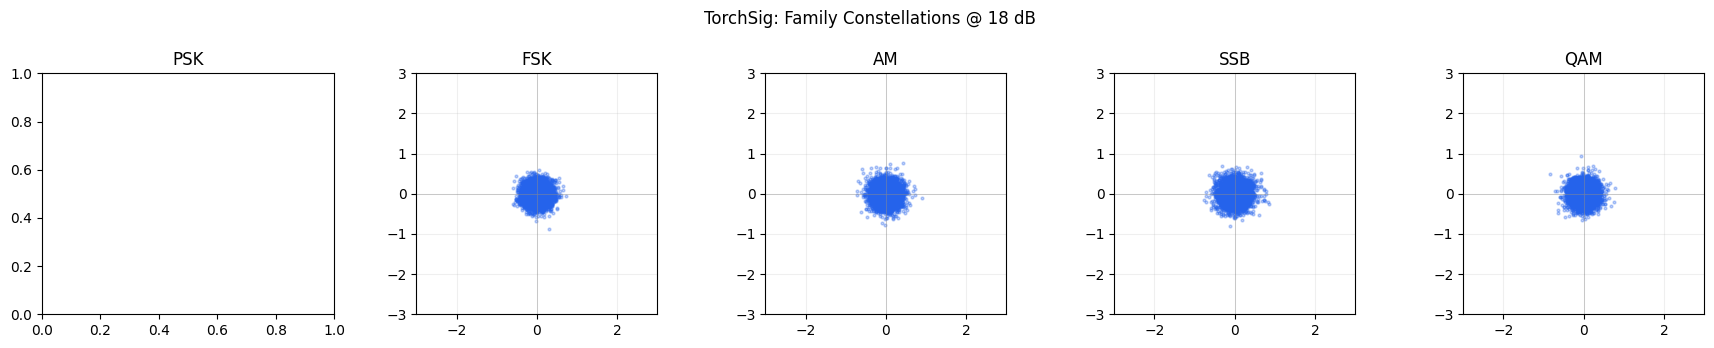

In [15]:
# Plot constellations for each family at high SNR
snr_to_plot = 18
families_to_plot = ts_mapper.family_names

fig, axes = plt.subplots(1, len(families_to_plot), figsize=(3.5 * len(families_to_plot), 3.5))

for ax, family in zip(axes, families_to_plot):
    fam_idx = ts_mapper.family_names.index(family)
    mask = (ts_family_indices == fam_idx) & (np.abs(ts_snrs - snr_to_plot) <= 2)

    if mask.sum() > 0:
        # Get several samples for better visualization
        samples = ts_data[mask][:10]
        I = samples[:, :].real
        Q = samples[:, :].imag

        ax.scatter(I, Q, alpha=0.3, s=4, c='#2563eb')
        ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
        ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.2)
    ax.set_title(family)

plt.suptitle(f"TorchSig: Family Constellations @ {snr_to_plot} dB", fontsize=12)
plt.tight_layout()
plt.show()

## 5. SNR Impact on Constellations

See how noise affects the constellation clarity for PSK signals.

In [ ]:
family_name = "PSK"
fam_idx = ts_mapper.family_names.index(family_name)
snr_levels_to_plot = [-6, 0, 10, 18]

fig, axes = plt.subplots(1, len(snr_levels_to_plot), figsize=(12, 3))

for ax, snr in zip(axes, snr_levels_to_plot):
    mask = (ts_family_indices == fam_idx) & (np.abs(ts_snrs - snr) <= 2)
    if mask.sum() > 0:
        samples = ts_data[mask][:5]
        I = samples[:, 0, :].flatten()
        Q = samples[:, 1, :].flatten()

        ax.scatter(I, Q, alpha=0.3, s=4, c='#2563eb')
        ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
        ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.set_title(f"{snr} dB")
    ax.grid(True, alpha=0.2)

plt.suptitle(f"{family_name} Constellation vs SNR", fontsize=12)
plt.tight_layout()
plt.show()

## 6. Compare TorchSig vs Panoradio (if available)

Compare synthetic and real-world signals for the same modulation families.

In [ ]:
if has_panoradio:
    # Map Panoradio labels to families
    pano_family_indices = np.array([pano_mapper.get_family_idx(str(lbl)) or -1 for lbl in pano_labels])
    
    # Find common families
    common_families = [f for f in ts_mapper.family_names if f in pano_mapper.family_names]
    
    fig, axes = plt.subplots(2, len(common_families), figsize=(3.5 * len(common_families), 7))
    
    for col, family in enumerate(common_families):
        # TorchSig (top row)
        ts_fam_idx = ts_mapper.family_names.index(family)
        ts_mask = (ts_family_indices == ts_fam_idx) & (ts_snrs > 10)
        if ts_mask.sum() > 0:
            samples = ts_data[ts_mask][:10]
            I = samples[:, 0, :].flatten()
            Q = samples[:, 1, :].flatten()
            axes[0, col].scatter(I, Q, alpha=0.3, s=4, c='#2563eb')
        axes[0, col].set_xlim(-3, 3)
        axes[0, col].set_ylim(-3, 3)
        axes[0, col].set_aspect('equal')
        axes[0, col].set_title(f"{family}")
        axes[0, col].grid(True, alpha=0.2)
        if col == 0:
            axes[0, col].set_ylabel("TorchSig\n(Synthetic)")
        
        # Panoradio (bottom row)
        pano_fam_idx = pano_mapper.family_names.index(family) if family in pano_mapper.family_names else -1
        if pano_fam_idx >= 0:
            pano_mask = (pano_family_indices == pano_fam_idx) & (pano_snrs > 10)
            if pano_mask.sum() > 0:
                samples = pano_data[pano_mask][:10]
                if np.iscomplexobj(samples):
                    I = samples.real.flatten()
                    Q = samples.imag.flatten()
                else:
                    I = samples[:, 0, :].flatten()
                    Q = samples[:, 1, :].flatten()
                axes[1, col].scatter(I, Q, alpha=0.3, s=4, c='#dc2626')
        axes[1, col].set_xlim(-3, 3)
        axes[1, col].set_ylim(-3, 3)
        axes[1, col].set_aspect('equal')
        axes[1, col].grid(True, alpha=0.2)
        if col == 0:
            axes[1, col].set_ylabel("Panoradio\n(Real HF)")
    
    plt.suptitle("TorchSig vs Panoradio: Same Families (High SNR)", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("Panoradio data not available for comparison.")

## 7. SNR Distribution

In [ ]:
fig, axes = plt.subplots(1, 2 if has_panoradio else 1, figsize=(12 if has_panoradio else 6, 4))
if not has_panoradio:
    axes = [axes]

# TorchSig
axes[0].hist(ts_snrs, bins=20, color='#2563eb', alpha=0.7, edgecolor='white')
axes[0].set_xlabel("SNR (dB)")
axes[0].set_ylabel("Count")
axes[0].set_title("TorchSig SNR Distribution")
axes[0].grid(True, alpha=0.3)

# Panoradio
if has_panoradio:
    axes[1].hist(pano_snrs, bins=20, color='#dc2626', alpha=0.7, edgecolor='white')
    axes[1].set_xlabel("SNR (dB)")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Panoradio SNR Distribution")
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Data Loader Configuration

The recommended way to load data for training/evaluation is via YAML configs.

In [ ]:
# Load using config
config = load_config_from_yaml(Path("../configs/datasets/torchsig_train.yaml"))
loaders = get_loaders(config)

print("Data loaders created from config:")
print(f"  Train: {len(loaders['train'].dataset)} samples")
print(f"  Val: {len(loaders['val'].dataset)} samples")
print(f"  Test: {len(loaders['test'].dataset)} samples")
print(f"  Family names: {loaders['family_names']}")